# Machine Learning Classifier for Lung Disease
## Support Vector Machine (SVM)

In [1]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.svm import SVC
import matplotlib.pyplot as plt
from tqdm import tqdm
import joblib

In [3]:
def load_lung_disease_dataset(base_path, img_size=(224, 224)):
    data = []
    labels = []
    
    if not os.path.exists(base_path):
        print(f"Error: Path {base_path} not found.")
        return None, None
        
    class_names = sorted([f for f in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, f))])
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    
    for idx, label in enumerate(class_names):
        folder_path = os.path.join(base_path, label)
        files = os.listdir(folder_path)
        
        for img_name in tqdm(files, desc=f"Loading {label}", leave=False):
            img_path = os.path.join(folder_path, img_name)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is None: continue
            
            img = clahe.apply(img)
            img = cv2.resize(img, img_size)
            data.append(img.flatten() / 255.0)
            labels.append(idx)
            
    return np.array(data, dtype=np.float32), np.array(labels, dtype=np.int32)

### Load Data set

In [4]:
X, y = load_lung_disease_dataset('1/dataset_combined')

### Split Dataset
- Three-Way Split (Train 70%, Val 15%, Test 15%)

In [5]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.176, random_state=42, stratify=y_train_full
)

print(f"Train shape: {X_train.shape}")

Train shape: (6448, 50176)


In [ ]:
print("Training Linear SVM... This may take several minutes.")

svm_model = SVC(kernel='linear', C=1.0, random_state=42)
svm_model.fit(X_train, y_train)

val_acc = svm_model.score(X_val, y_val) * 100
print(f"Validation Accuracy: {val_acc:.2f}%")

Training Linear SVM... This may take several minutes.
Validation Accuracy: 84.11%


### Final Evaluation on Test Set



Evaluating on Test Set...
Final Test Accuracy: 84.52%


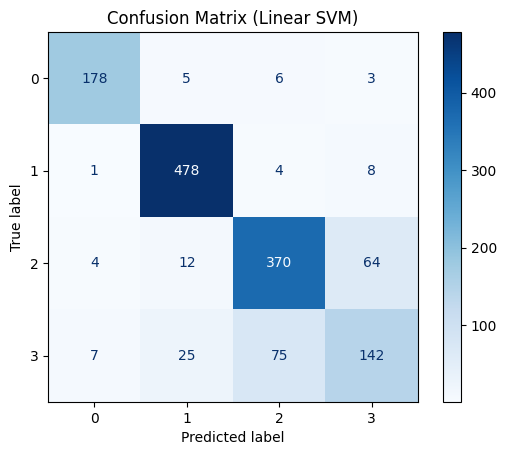

              precision    recall  f1-score   support

           0       0.94      0.93      0.93       192
           1       0.92      0.97      0.95       491
           2       0.81      0.82      0.82       450
           3       0.65      0.57      0.61       249

    accuracy                           0.85      1382
   macro avg       0.83      0.82      0.83      1382
weighted avg       0.84      0.85      0.84      1382



['best_svm_lung_model.pkl']

In [7]:
print("\nEvaluating on Test Set...")
test_acc = svm_model.score(X_test, y_test) * 100
print(f"Final Test Accuracy: {test_acc:.2f}%")

y_pred = svm_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (Linear SVM)")
plt.show()

print(classification_report(y_test, y_pred))
joblib.dump(svm_model, "best_svm_lung_model.pkl")